# Interpolation

when we shrink or enlarge the image, extra pixels intensity computed with interpolation.
* Enlarging (Upscaling) → new pixels are created, interpolation estimates their intensity
* Shrinking (Downscaling) → multiple pixels must be combined into fewer pixels, interpolation decides how they are merged

Linear interpolation
* Uses 2 × 2 neighborhood
* Total 4 surrounding pixels
* New pixel = weighted average of those pixels


Cubic interpolation
* Uses 4 × 4 neighborhood
* Total 16 surrounding pixels
* Produces smoother images
* Slightly slower


Area interpolation
* Calculates average of multiple pixels
* Best for downscaling
* Reduces aliasing and noise




In [12]:
from google.colab import files
uploaded = files.upload()

Saving watch.jpg to watch (1).jpg


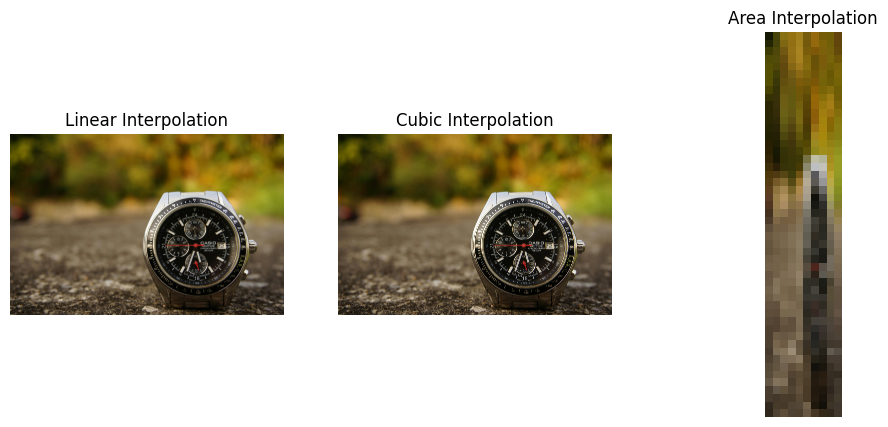

In [13]:
# Notes
# Linear and cubic interpolation computes the new pixel value as a weighted average of nearby pixels.
# Area interpolation computes the average value of all pixels that fall inside the resized pixel area.


import cv2
import matplotlib.pyplot as plt

from google.colab.patches import cv2_imshow
image = cv2.imread("watch.jpg")

# reducing the image size to 10% of original (linear interpolation is default)
Linear_inter = cv2.resize(image, None, fx=1.2, fy=1.2,interpolation=cv2.INTER_LINEAR)


# enlarging image by 2 times using cubic interpolation
Cubic_inter = cv2.resize(image, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)


# resizing image using area interpolation
Area_inter = cv2.resize(image, (10,50), interpolation=cv2.INTER_AREA)


plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.title("Linear Interpolation")
plt.imshow(cv2.cvtColor(Linear_inter, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Cubic Interpolation")
plt.imshow(cv2.cvtColor(Cubic_inter, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Area Interpolation")
plt.imshow(cv2.cvtColor(Area_inter, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()





# Affine tranformation
* affine transformation is where straight line and parallel lines will remain same after transformation

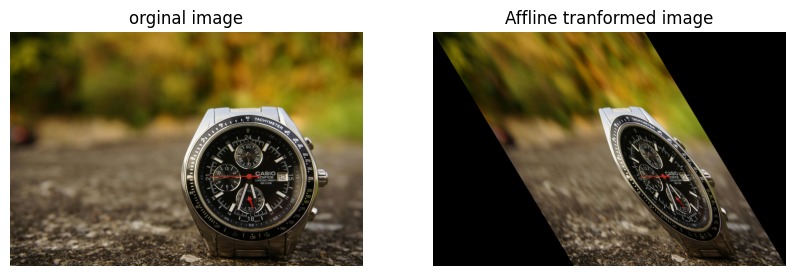

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image=cv2.imread("watch.jpg")
rows,cols=image.shape[:2]


# Affine transformation we need to give 3 source and destination point so that CV can calculate transformation matrix
src_point=np.float32([[0,0],[cols-1,0],[0,rows-1]])
dst_points = np.float32([[0,0], [int(0.6*(cols-1)),0], [int(0.4*(cols-1)),rows-1]])

# this calculates new matrix for the input image
affine_matrix=cv2.getAffineTransform(src_point,dst_points)
output=cv2.warpAffine(image,affine_matrix,(cols,rows))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("orginal image")
plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Affline tranformed image")
plt.imshow(cv2.cvtColor(output,cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

# Perspective Tranformation

* When we take a photo of a rectangle from a different angle, the rectangle may appear as a trapezoid due to perspective distortion.

* Using perspective transformation, we can correct this distortion and transform the trapezoid back into a rectangle, as if the image was captured from a top-down view.
* used for document scanning

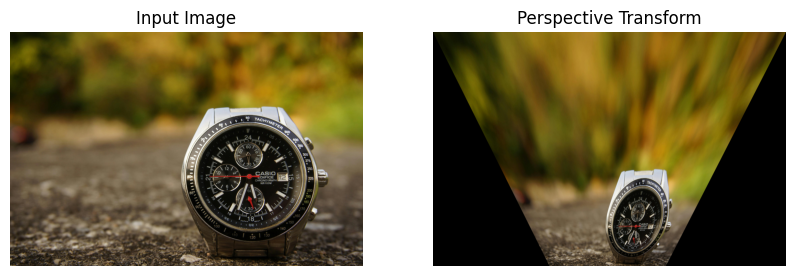

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("watch.jpg")

rows, cols = image.shape[:2]

# Source points (corners of image)
src_points = np.float32([
    [0,0],
    [cols-1,0],
    [0,rows-1],
    [cols-1,rows-1]
])

# Destination points (change perspective)
dst_points = np.float32([
    [0,0],
    [cols-1,0],
    [int(0.33*(cols-1)),rows-1],
    [int(0.66*(cols-1)),rows-1]
])

# Compute perspective matrix
perspective_matrix = cv2.getPerspectiveTransform(src_points, dst_points)

# Apply perspective transformation
output = cv2.warpPerspective(image, perspective_matrix, (cols, rows))

# Display using matplotlib
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Input Image")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Perspective Transform")
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

In [16]:
import cv2
import numpy as np
# wrapping using sine function
import math

# read image and convert to grayscale
image=cv2.imread("watch.jpg",cv2.IMREAD_GRAYSCALE)
row,col=image.shape

# create empty image with 0 pixel just as size and datatype as input image
image_output=np.zeros(image.shape,dtype=image.dtype)

#Vertical wave
# loop for each row and each column
for i in range(row):
    for j in range(col):

############# DO THIS CODE AGAIN YOU DID NOT UNDERSTAND

# =========================
# Vertical Wave
# =========================
img_output = np.zeros(img.shape, dtype=img.dtype)

for i in range(rows):
    for j in range(cols):

        offset_x = int(25.0 * math.sin(2 * 3.14 * i / 180))
        offset_y = 0

        if j + offset_x < cols:
            img_output[i, j] = img[i, (j + offset_x) % cols]
        else:
            img_output[i, j] = 0

cv2.imshow("Vertical wave", img_output)

# =========================
# Horizontal Wave
# =========================
img_output = np.zeros(img.shape, dtype=img.dtype)

for i in range(rows):
    for j in range(cols):

        offset_x = 0
        offset_y = int(16.0 * math.sin(2 * 3.14 * j / 150))

        if i + offset_y < rows:
            img_output[i, j] = img[(i + offset_y) % rows, j]
        else:
            img_output[i, j] = 0

cv2.imshow("Horizontal wave", img_output)

# =========================
# Multidirectional Wave
# =========================
img_output = np.zeros(img.shape, dtype=img.dtype)

for i in range(rows):
    for j in range(cols):

        offset_x = int(20.0 * math.sin(2 * 3.14 * i / 150))
        offset_y = int(20.0 * math.sin(2 * 3.14 * j / 150))

        if i + offset_y < rows and j + offset_x < cols:
            img_output[i, j] = img[(i + offset_y) % rows, (j + offset_x) % cols]
        else:
            img_output[i, j] = 0

cv2.imshow("Multidirectional wave", img_output)

# =========================
# Concave Effect
# =========================
img_output = np.zeros(img.shape, dtype=img.dtype)

for i in range(rows):
    for j in range(cols):

        offset_x = int(128.0 * math.sin(2 * 3.14 * i / (2 * cols)))
        offset_y = 0

        if j + offset_x < cols:
            img_output[i, j] = img[i, (j + offset_x) % cols]
        else:
            img_output[i, j] = 0

cv2.imshow("Concave", img_output)

IndentationError: expected an indented block after 'for' statement on line 16 (493793676.py, line 23)

# Web camera access

In [ ]:
import cv2

# open webcam from laptop
cap=cv2.VideoCapture(0)

# web camera did not open, then raise error
if not cap.isOpened():
    raise IOError("cannot open webcam")


while True:
    ret,frame=cap.read()
    # cap.read() will return if the image is captured as true or false in ret
    # frame will have information on image
    frame=cv2.resize(frame,None,fx=0.3,fy=0.3,interpolation=cv2.INTER_AREA)
    cv2.imshow("input",frame)
    c=cv2.waitKey(1)# wait for 1 milli second and continue the loop until we press esc
    if c==27:
        break
cap.release() # free the camera resource so that other application can use it
